# 01 · One universe of data
*Heterogeneous surveys → one standard, queryable, cosmology-free database.*

Every survey ships its own FITS layout, column names and conventions. `oneuniverse.data` collapses them onto one schema and one on-disk format — **OUF 2.6**: an identity-only `manifest.json` + a parquet **partition index sidecar** + HEALPix-partitioned data. This notebook shows, on the **real eBOSS DR16Q and DESI DR1 quasar catalogs**: the shared sky, cross-survey identity, the anatomy of the format, and why partial access makes a 2-million-row catalog feel small.

In [1]:
%matplotlib inline
import os, sys, json, time, sqlite3, tempfile, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, healpy as hp
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrow, Rectangle, FancyBboxPatch
plt.rcParams.update({'figure.dpi':115,'font.size':10.5,'axes.titlesize':11.5,
    'axes.titleweight':'bold','axes.spines.top':False,'axes.spines.right':False,
    'figure.facecolor':'white'})
C0,C1,C2,C3,C4 = '#3a6ea5','#d1495b','#3c8d53','#edae49','#7d5ba6'
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT/'test'))
TMP = Path(tempfile.mkdtemp())
DATA_ROOT='/home/ravoux/Documents/Science/Cosmography/oneuniverse_data'
EBOSS=Path(DATA_ROOT)/'spectroscopic/eboss/qso/DR16Q_Superset_v3.fits'
DESI =Path(DATA_ROOT)/'spectroscopic/desi/dr1/qso/QSO_full.dat.fits'
HAVE_REAL = EBOSS.exists() and DESI.exists()
from oneuniverse.simulation.cosmology import CosmologySpec
COSMO = CosmologySpec(omega_m=0.31, omega_b=0.048, h=0.67, n_s=0.96, sigma8=0.81, t_cmb=2.7255)
def moll(ax, ra, dec, **kw):
    lon = np.radians(((np.asarray(ra)+180)%360)-180)
    ax.scatter(lon, np.radians(dec), **kw)
print('real eBOSS+DESI available:', HAVE_REAL)

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


real eBOSS+DESI available: True


In [2]:
def load_qso(name, zlo=0.8, zhi=2.2, cap=60000, seed=0):
    '''Real survey catalog via the registered P1 loader (synthetic fallback).'''
    if not HAVE_REAL:
        from fixtures.measure_ouf import synthetic_point_view
        return synthetic_point_view(TMP, n=cap, seed=seed, name=name).read(), False
    os.environ['ONEUNIVERSE_DATA_ROOT']=DATA_ROOT
    from oneuniverse.data import load_catalog
    df = load_catalog(name, validate=False)
    df = df[(df['z']>=zlo)&(df['z']<=zhi)].dropna(subset=['ra','dec','z'])
    if len(df)>cap: df=df.sample(cap, random_state=seed)
    return df.reset_index(drop=True), True
eb,_ = load_qso('eboss_qso', cap=60000, seed=1)
de,real = load_qso('desi_qso', cap=60000, seed=2)
print(('REAL data' if real else 'synthetic stand-in'),
      '| eBOSS rows:',len(eb),'| DESI rows:',len(de))

REAL data | eBOSS rows: 60000 | DESI rows: 60000


## The same sky, two instruments
Mollweide view of both quasar samples — the NGC/SGC geometry of eBOSS against DESI's wider footprint, plus their redshift selections.

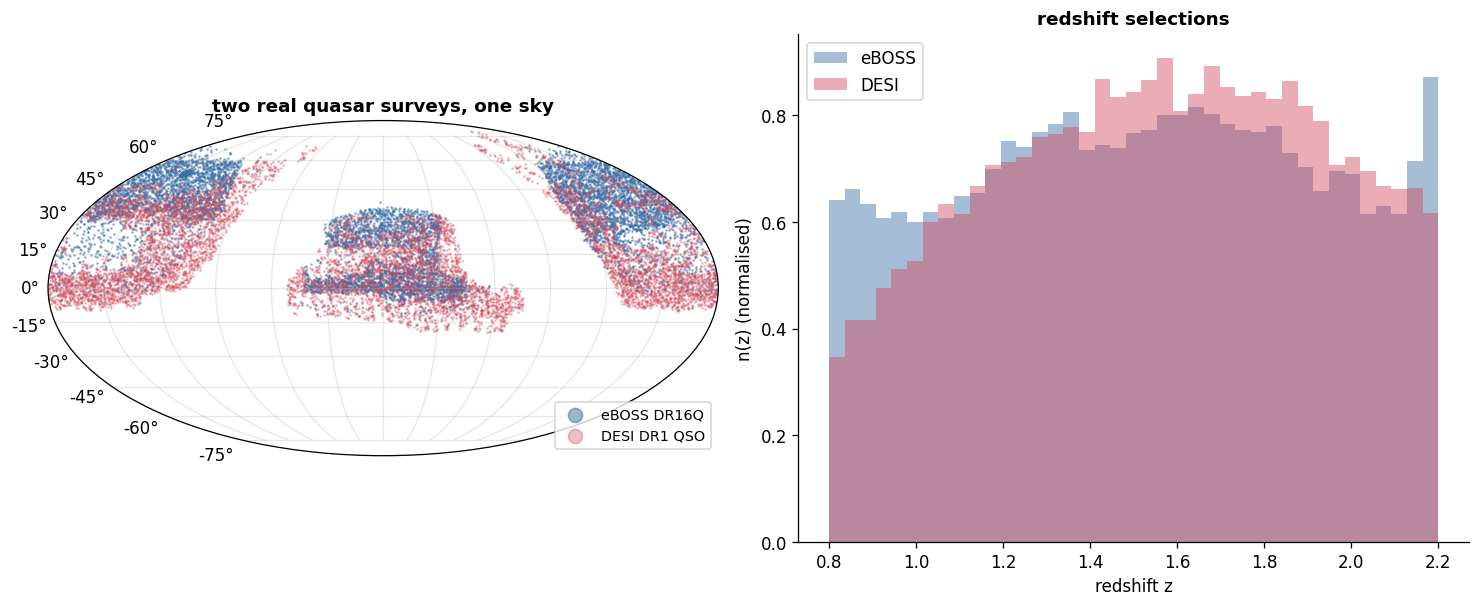

In [3]:
fig = plt.figure(figsize=(13,5.4))
ax1 = fig.add_subplot(1,2,1, projection='mollweide')
moll(ax1, eb['ra'][::6], eb['dec'][::6], s=.4, c=C0, alpha=.5, label='eBOSS DR16Q')
moll(ax1, de['ra'][::6], de['dec'][::6], s=.4, c=C1, alpha=.35, label='DESI DR1 QSO')
ax1.grid(alpha=.3); ax1.set_xticklabels([]); ax1.set_title('two real quasar surveys, one sky')
ax1.legend(markerscale=14, loc='lower right', fontsize=9)
ax2 = fig.add_subplot(1,2,2)
bins=np.linspace(0.8,2.2,40)
ax2.hist(eb['z'],bins=bins,density=True,histtype='stepfilled',alpha=.45,color=C0,label='eBOSS')
ax2.hist(de['z'],bins=bins,density=True,histtype='stepfilled',alpha=.45,color=C1,label='DESI')
ax2.set_xlabel('redshift z'); ax2.set_ylabel('n(z) (normalised)')
ax2.set_title('redshift selections'); ax2.legend()
plt.tight_layout(); plt.show()

## Cross-survey identity
The same quasar appears in both surveys. A positional match shows the genuine-repeat peak at sub-arcsecond separations over a flat chance-alignment background — the geometric core of the package's **ONEUID** bitemporal cross-match.

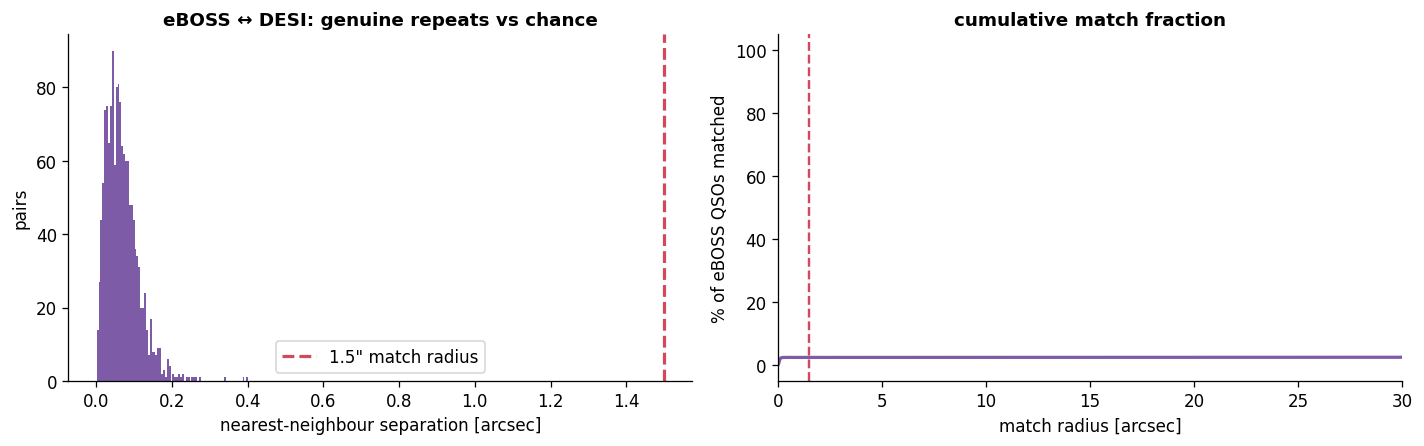

matched within 1.5": 1,478 of 60,000 (2.5%)


In [4]:
from scipy.spatial import cKDTree
def unit(ra,dec):
    r=np.radians(ra); d=np.radians(dec)
    return np.c_[np.cos(d)*np.cos(r), np.cos(d)*np.sin(r), np.sin(d)]
tree=cKDTree(unit(de['ra'].to_numpy(),de['dec'].to_numpy()))
dist,_=tree.query(unit(eb['ra'].to_numpy(),eb['dec'].to_numpy()),k=1)
sep=np.degrees(2*np.arcsin(np.clip(dist/2,0,1)))*3600
fig,ax=plt.subplots(1,2,figsize=(12.5,4))
ax[0].hist(sep[sep<8],bins=80,color=C4)
ax[0].axvline(1.5,color=C1,ls='--',lw=2,label='1.5" match radius')
ax[0].set_xlabel('nearest-neighbour separation [arcsec]'); ax[0].set_ylabel('pairs')
ax[0].set_title('eBOSS ↔ DESI: genuine repeats vs chance'); ax[0].legend()
ss=np.sort(sep); ax[1].plot(ss, np.arange(1,len(ss)+1)/len(ss)*100, c=C4, lw=2)
ax[1].set_xlim(0,30); ax[1].set_xlabel('match radius [arcsec]')
ax[1].set_ylabel('% of eBOSS QSOs matched'); ax[1].set_title('cumulative match fraction')
ax[1].axvline(1.5,color=C1,ls='--'); plt.tight_layout(); plt.show()
print(f'matched within 1.5": {(sep<1.5).sum():,} of {len(sep):,} ({100*(sep<1.5).mean():.1f}%)')

## Anatomy of OUF 2.6
Convert the eBOSS sample to OUF and dissect it: the **identity-only manifest** (stable JSON, no bulk), the **partition-index sidecar** (`_index.parquet`, one row per HEALPix partition with its file, row count and z-range), and the partitions painted on the sky.

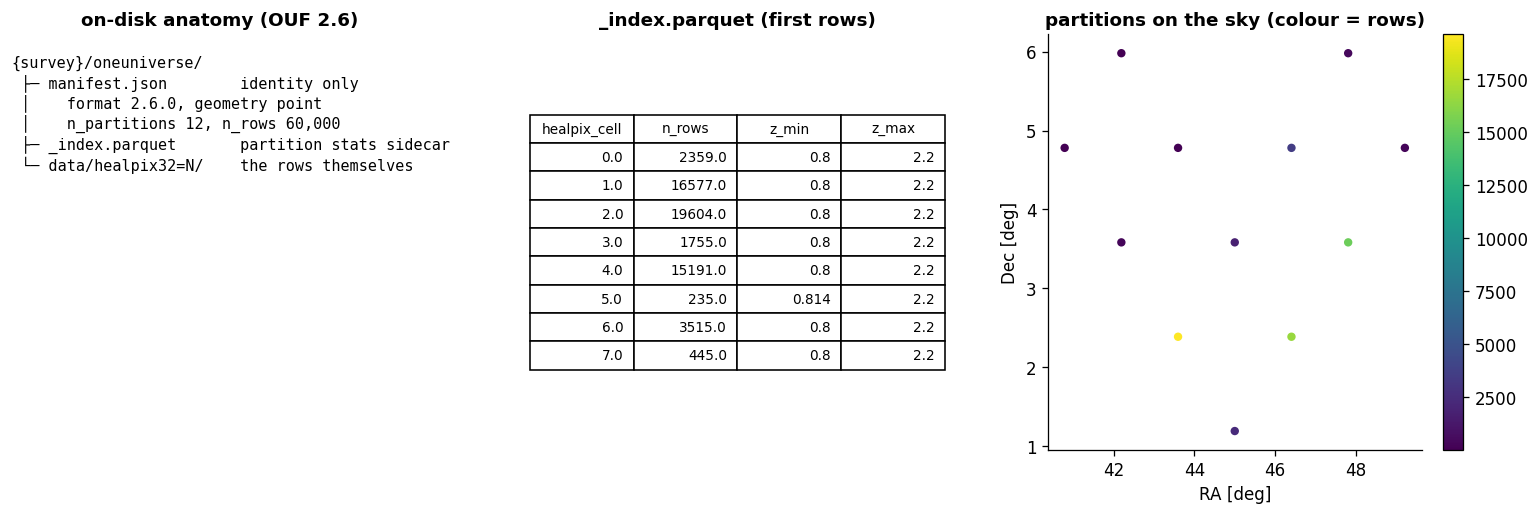

manifest keys: ['classification_pdf', 'conversion_kwargs', 'coordinate', 'created_utc', 'cube', 'extra', 'geometry', 'gwskymap', 'loader'] …


In [5]:
def to_ouf_view(df, tmp, name, extra_cols=()):
    '''Write a DataFrame as an OUF 2.6 POINT dataset; return its DatasetView.'''
    from oneuniverse.data.converter import write_ouf_dataset
    from oneuniverse.data.dataset_view import DatasetView
    from oneuniverse.data.format_spec import DataGeometry
    from oneuniverse.data.manifest import LoaderSpec
    n=len(df); ra=df['ra'].to_numpy(float); dec=df['dec'].to_numpy(float)
    out={'ra':ra,'dec':dec,'z':df['z'].to_numpy(float),'z_type':np.full(n,'spec'),
         'z_err':np.full(n,1e-4),'galaxy_id':np.arange(n,dtype=np.int64),
         'survey_id':np.zeros(n,dtype=np.int64),'weight_comp':np.ones(n),
         '_original_row_index':np.arange(n,dtype='i8'),
         '_healpix32':hp.ang2pix(32,ra,dec,nest=True,lonlat=True).astype('i4')}
    for c in extra_cols:
        out[c]=df[c].to_numpy()
    od=tmp/name/'oneuniverse'
    write_ouf_dataset(df=pd.DataFrame(out),out_dir=od,survey_name=name,
        survey_type='spectroscopic',geometry=DataGeometry.POINT,
        loader=LoaderSpec(name=name,version='0'))
    return DatasetView.from_path(od.parent)
view = to_ouf_view(eb, TMP, 'eboss')
ou = view.ou_dir
raw = json.loads((ou/'manifest.json').read_text())
import pyarrow.parquet as pq
idx = pq.read_table(ou/'_index.parquet').to_pandas()
fig = plt.figure(figsize=(13.5,4.6))
axA = fig.add_subplot(1,3,1); axA.axis('off')
tree = ('{survey}/oneuniverse/\n'
        ' ├─ manifest.json        identity only\n'
        f" │    format {raw['oneuniverse_format_version']}, geometry {raw['geometry']}\n"
        f" │    n_partitions {raw['n_partitions']}, n_rows {raw['n_rows_total']:,}\n"
        ' ├─ _index.parquet       partition stats sidecar\n'
        ' └─ data/healpix32=N/    the rows themselves')
axA.text(0.0,0.95,tree,family='monospace',fontsize=9.5,va='top')
axA.set_title('on-disk anatomy (OUF 2.6)')
axB = fig.add_subplot(1,3,2); axB.axis('off')
head = idx[['healpix_cell','n_rows','z_min','z_max']].head(8).round(3)
tb=axB.table(cellText=head.values, colLabels=head.columns, loc='center')
tb.scale(1,1.45); tb.auto_set_font_size(False); tb.set_fontsize(8.5)
axB.set_title('_index.parquet (first rows)')
axC = fig.add_subplot(1,3,3)
cells = idx['healpix_cell'].to_numpy(); nr = idx['n_rows'].to_numpy()
th,ph = hp.pix2ang(32, cells.astype(int), nest=True)
sc=moll if False else None
lon = np.radians(((np.degrees(ph)+180)%360)-180)
s=axC.scatter(np.degrees(ph), 90-np.degrees(th), c=nr, s=18, cmap='viridis')
axC.set_xlabel('RA [deg]'); axC.set_ylabel('Dec [deg]')
axC.set_title('partitions on the sky (colour = rows)')
plt.colorbar(s, ax=axC, fraction=.05)
plt.tight_layout(); plt.show()
print('manifest keys:', sorted(k for k in raw if not k.startswith('_'))[:9], '…')

## Partial access: read only what you ask for
The reader resolves a selector against the sidecar index and touches only the overlapping partitions.

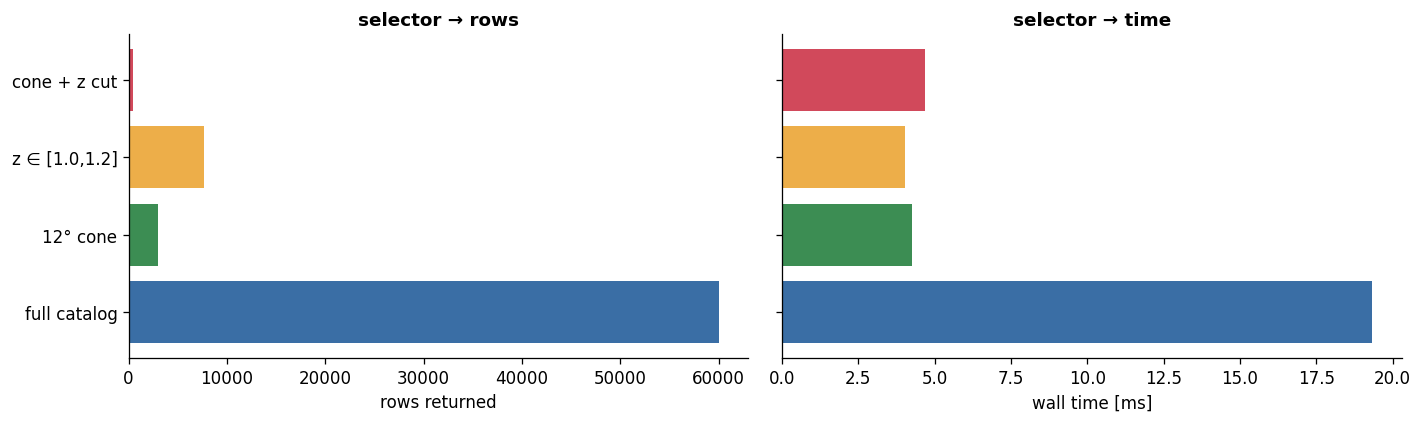

full catalog    60,000 rows    19.3 ms
12° cone         3,018 rows     4.2 ms
z ∈ [1.0,1.2]    7,705 rows     4.0 ms
cone + z cut       408 rows     4.7 ms


In [6]:
from oneuniverse.data.selection import Cone
cra,cdec = float(eb['ra'].median()), float(eb['dec'].median())
jobs = {'full catalog': dict(), '12° cone': dict(cone=Cone(ra=cra,dec=cdec,radius=12)),
        'z ∈ [1.0,1.2]': dict(z_range=(1.0,1.2)),
        'cone + z cut': dict(cone=Cone(ra=cra,dec=cdec,radius=12), z_range=(1.0,1.2))}
rows=[]; times=[]
for name,kw in jobs.items():
    t0=time.perf_counter(); d=view.read(columns=['ra','dec','z'],**kw)
    times.append(1e3*(time.perf_counter()-t0)); rows.append(len(d))
fig,ax=plt.subplots(1,2,figsize=(12.5,3.8))
y=np.arange(len(jobs))
ax[0].barh(y,rows,color=[C0,C2,C3,C1]); ax[0].set_yticks(y); ax[0].set_yticklabels(jobs)
ax[0].set_xlabel('rows returned'); ax[0].set_title('selector → rows')
ax[1].barh(y,times,color=[C0,C2,C3,C1]); ax[1].set_yticks(y); ax[1].set_yticklabels([])
ax[1].set_xlabel('wall time [ms]'); ax[1].set_title('selector → time')
plt.tight_layout(); plt.show()
for (n,_),r,t in zip(jobs.items(),rows,times): print(f'{n:14s} {r:7,} rows  {t:6.1f} ms')

**What this showed.** Two real surveys on one schema; the same quasars re-identified across them at sub-arcsecond precision; an on-disk format whose manifest is identity-only with a queryable partition sidecar; and selector-driven reads that scale with the question, not the catalog. No cosmology touched the data at any point.